In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("pune_mumbai_combined_clean_data.csv") 

In [3]:
df.head() 

,City,Locality,Property_Type,BHK,Carpet_Area_sqft,Floor_No,Bathrooms,Furnishing,Price_Rs,Price_per_sqft,Listing_Type,Title
0,Pune,Wakad,Flat,3,1086.0,7.0,3.0,Furnished,60000.0,55.25,Rent,"3 BHK Flat for Rent in Wakad, Pune"
1,Pune,Wakad,Flat,2,923.5,2.0,2.0,Semi-Furnished,19500.0,21.12,Rent,"2 BHK Flat for Rent in Ganesh Imperia, Wakad, ..."
2,Pune,Wakad,Flat,2,923.5,5.0,2.0,Furnished,27000.0,29.24,Rent,"2 BHK Flat for Rent in Paranjape Broadway, Wak..."
3,Pune,Wakad,Flat,3,923.5,8.0,3.0,Semi-Furnished,42000.0,45.48,Rent,"3 BHK Flat for Rent in Paramount Altissimo, Wa..."
4,Pune,Wakad,Flat,2,923.5,11.0,2.0,Furnished,38000.0,41.15,Rent,"2 BHK Flat for Rent in Wakad, Pune"


In [4]:
df.shape

(451, 12)

In [5]:
df['Carpet_Area_sqft'].min()

250.0

In [12]:
df.describe()

,BHK,Carpet_Area_sqft,Floor_No,Bathrooms,Price_Rs,Price_per_sqft
count,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000
mean,2.152993,883.698448,8.725055,2.184035,46909.478936,56.038071
std,0.643676,266.176163,7.260840,0.606859,21515.221793,27.649410
min,1.000000,250.000000,1.000000,1.000000,5000.000000,9.240000
25%,2.000000,731.000000,4.000000,2.000000,30500.000000,35.545000
50%,2.000000,860.000000,7.000000,2.000000,42000.000000,47.270000
75%,3.000000,1050.000000,11.000000,3.000000,60000.000000,76.965000
max,4.000000,3000.000000,50.000000,4.000000,99000.000000,152.630000


In [15]:
df["Furnishing"].value_counts()

Furnishing
Semi-Furnished    202
Unfurnished       146
Furnished         102
Unknown             1
Name: count, dtype: int64

In [18]:
num_df = df.select_dtypes(include = 'number')
num_df.columns

Index(['BHK', 'Carpet_Area_sqft', 'Floor_No', 'Bathrooms', 'Price_Rs',
       'Price_per_sqft'],
      dtype='object')

# Univariate Analysis :

### Rent Distribution


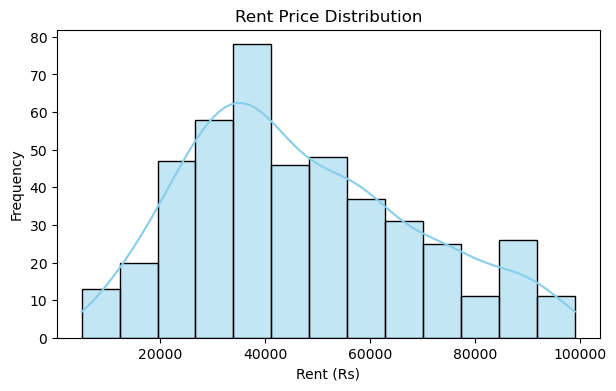

In [14]:
plt.figure(figsize=(7,4))
sns.histplot(df['Price_Rs'], kde=True, color='skyblue')
plt.title("Rent Price Distribution")
plt.xlabel("Rent (Rs)")
plt.ylabel("Frequency")
plt.show()


### BHK Count 

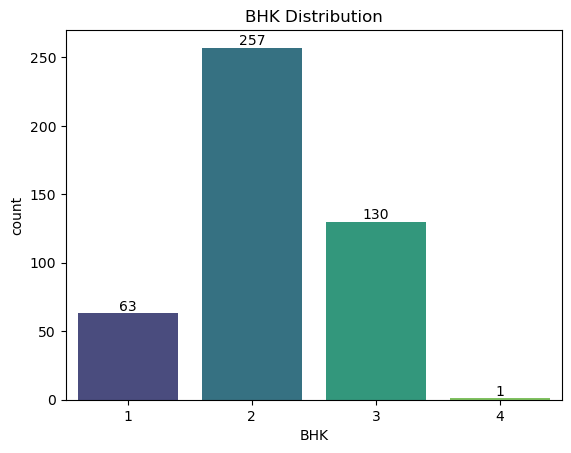

In [40]:
a=sns.countplot(x='BHK', data=df, palette='viridis')
for i in a.containers:
    a.bar_label(i)
plt.title("BHK Distribution")
plt.show()

### Furnishing Distribution 


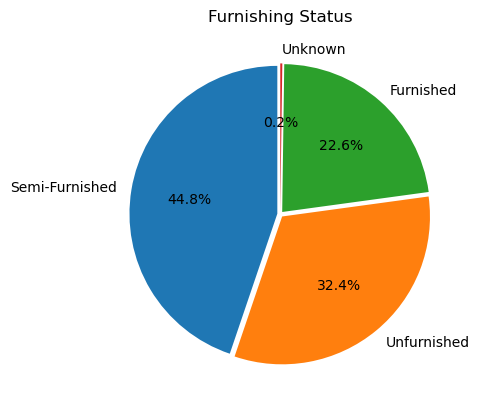

In [66]:

df['Furnishing'].value_counts().plot(kind='pie', autopct='%1.1f%%',startangle=90,explode=[0.02]*df['Furnishing'].nunique())
plt.title("Furnishing Status Distribution")
plt.ylabel('')
plt.show() 

# Bivariate Analysis 

## Average Rent by BHK Type

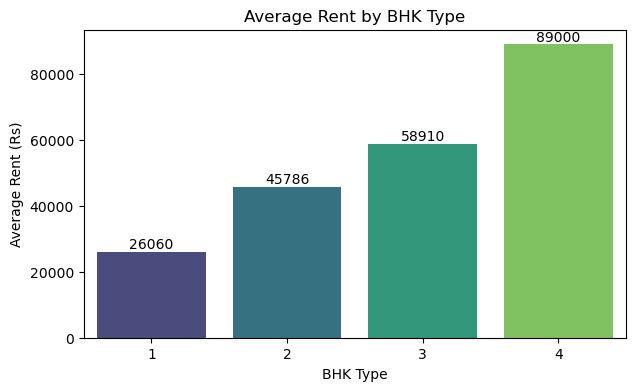

In [58]:
avg_rent_bhk = df.groupby('BHK')['Price_Rs'].mean().reset_index()

plt.figure(figsize=(7,4))
a = sns.barplot(x='BHK', y='Price_Rs', data=avg_rent_bhk, palette='viridis')

for i in a.containers:
    a.bar_label(i, fmt='%.0f')

plt.title("Average Rent by BHK Type")
plt.xlabel("BHK Type")
plt.ylabel("Average Rent (Rs)")
plt.show()


### Carpet Area vs Rent

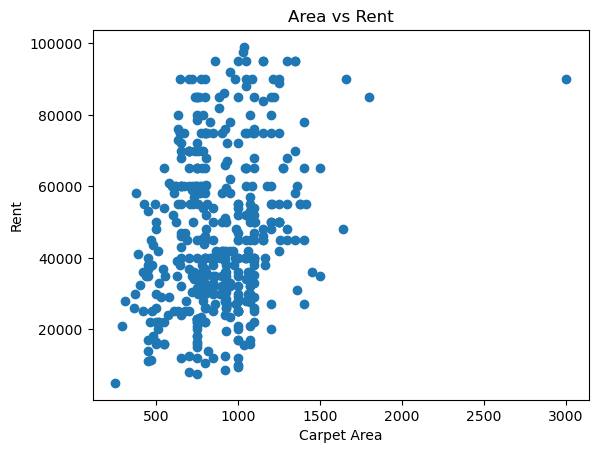

In [34]:
plt.scatter(df['Carpet_Area_sqft'], df['Price_Rs'])
plt.xlabel("Carpet Area")
plt.ylabel("Rent")
plt.title("Area vs Rent")
plt.show()


### BHK vs Rent 

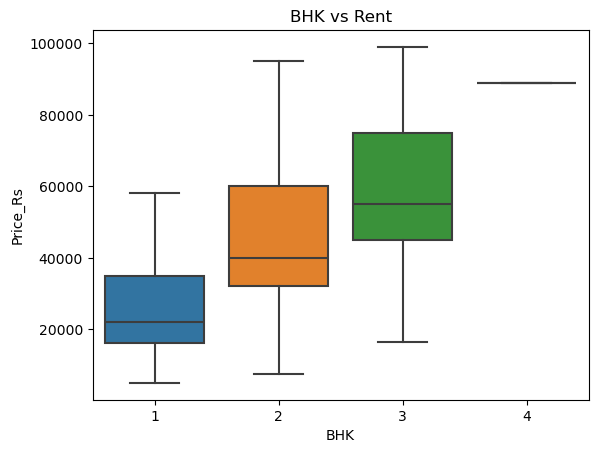

In [37]:
sns.boxplot(x='BHK', y='Price_Rs', data=df)
plt.title("BHK vs Rent")
plt.show()


### Furnishing vs Rent 

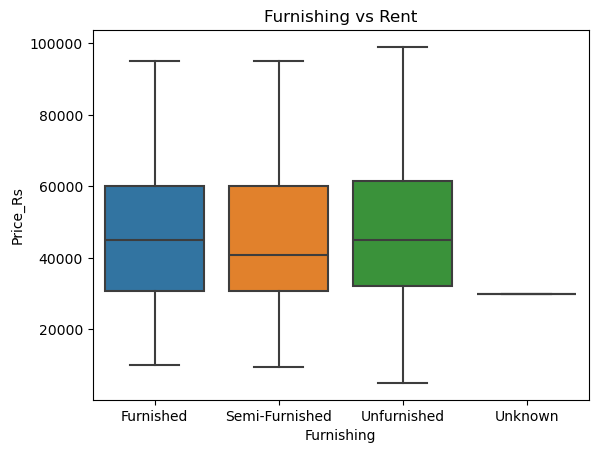

In [40]:
sns.boxplot(x='Furnishing', y='Price_Rs', data=df)
plt.title("Furnishing vs Rent")
plt.show()


## Locality Analysis

### Average Rent by locality

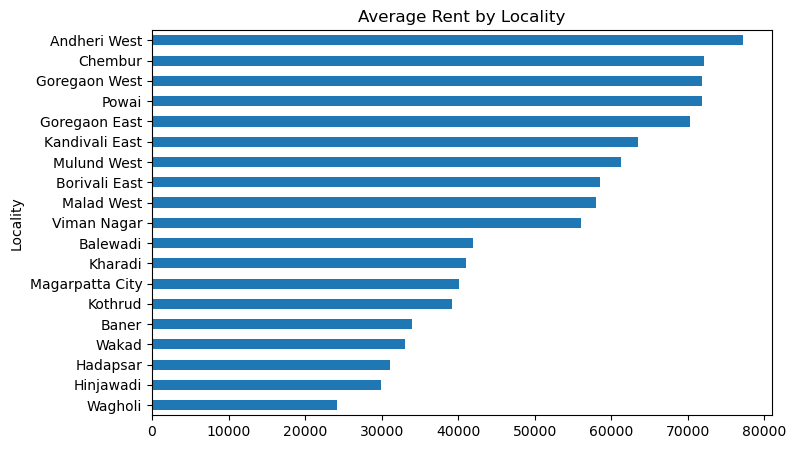

In [45]:
df.groupby('Locality')['Price_Rs'].mean().sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Average Rent by Locality")
plt.show()


## Correlation Heatmap

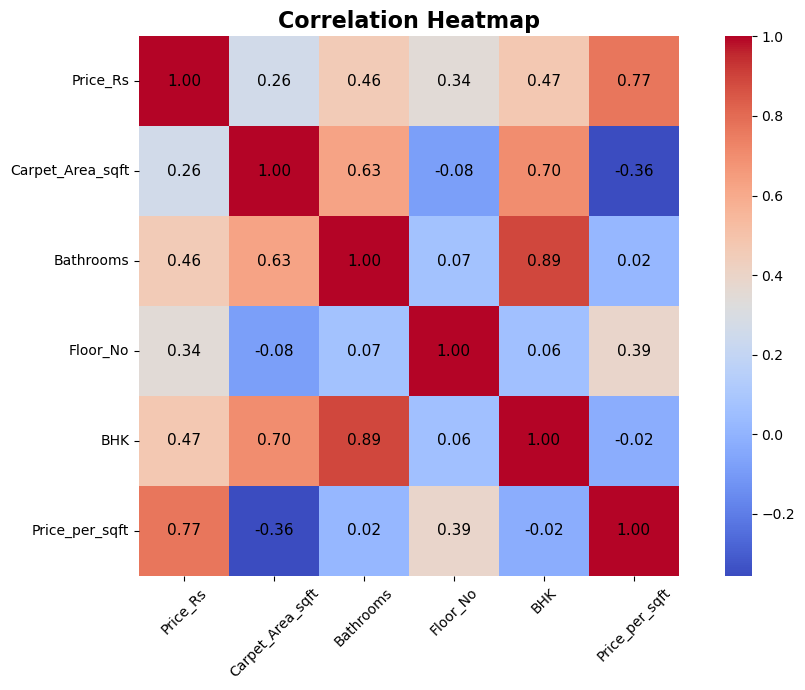

In [15]:
plt.figure(figsize=(10,7))

corr_matrix = df[['Price_Rs','Carpet_Area_sqft','Bathrooms','Floor_No','BHK','Price_per_sqft']].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    # linewidths=1,
    linecolor='white',
    cbar=True,
    square=True,
    annot_kws={"size":11, "color":"black"}  # ensures numbers are visible
)

plt.title("Correlation Heatmap", fontsize=16, weight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Bathrooms vs Rent Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_5720\1107050733.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bathrooms', y='Price_Rs', data=df, palette='Set2')


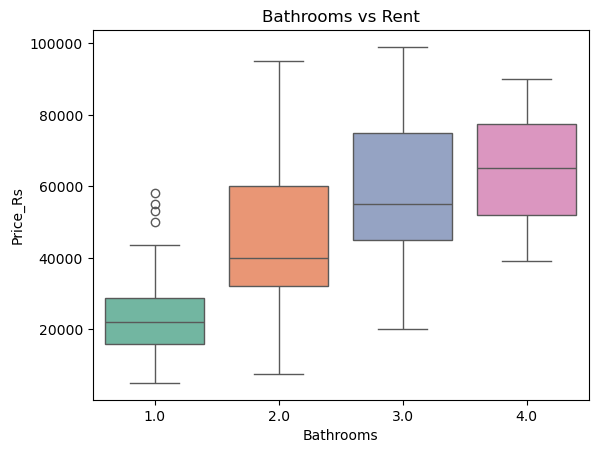

In [8]:
sns.boxplot(x='Bathrooms', y='Price_Rs', data=df, palette='Set2')
plt.title("Bathrooms vs Rent")
plt.show()